In [5]:
#FIFA Prediction 2026_ Project
#let's do some EDA


In [6]:
import pandas as pd

In [7]:
import numpy as np

In [8]:
df = pd.read_csv("FIFA_2015 to 2026_Cleaned and Organised Data.csv")

In [9]:
df.head()

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Rank Difference,Teams,Total Match Played,Total Win,Win %,Trim Home_TEAM,Trim Away_TEAM,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,23,Morocco,74.0,31.0,41.89,Morocco,Sweden,Morocco,NaN,// -ve means home team stronger
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,9,Poland,70.0,24.0,34.29,Poland,USA,Poland,NaN,// +ve means away team stronger
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,3,Mexico,63.0,30.0,47.62,Mexico,Canada,Mexico,NaN,NaN
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,-10,Argentina,67.0,32.0,47.76,Poland,Canada,Argentina,NaN,NaN
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,-8,Germany,68.0,23.0,33.82,Argentina,Sweden,Germany,NaN,NaN


In [10]:
df

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Rank Difference,Teams,Total Match Played,Total Win,Win %,Trim Home_TEAM,Trim Away_TEAM,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,23,Morocco,74.0,31.0,41.89,Morocco,Sweden,Morocco,NaN,// -ve means home team stronger
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,9,Poland,70.0,24.0,34.29,Poland,USA,Poland,NaN,// +ve means away team stronger
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,3,Mexico,63.0,30.0,47.62,Mexico,Canada,Mexico,NaN,NaN
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,-10,Argentina,67.0,32.0,47.76,Poland,Canada,Argentina,NaN,NaN
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,-8,Germany,68.0,23.0,33.82,Argentina,Sweden,Germany,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23-09-2017,World Cup,France,Morocco,2,29,2185,2144,5,...,-27,NaN,NaN,NaN,NaN,France,Morocco,NaN,NaN,NaN
996,997,24-09-2017,Nations League,Portugal,Norway,26,27,1853,2079,0,...,-1,NaN,NaN,NaN,NaN,Portugal,Norway,NaN,NaN,NaN
997,998,25-09-2017,WC Qualifier,Portugal,England,2,24,1872,1862,3,...,-22,NaN,NaN,NaN,NaN,Portugal,England,NaN,NaN,NaN
998,999,26-09-2017,WC Qualifier,Denmark,Argentina,28,15,1957,2068,0,...,13,NaN,NaN,NaN,NaN,Denmark,Argentina,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Match_ID             1000 non-null   int64  
 1   Date                 1000 non-null   object 
 2   Competition          1000 non-null   object 
 3   Home_Team            1000 non-null   object 
 4   Away_Team            1000 non-null   object 
 5   Home_Rank            1000 non-null   int64  
 6   Away_Rank            1000 non-null   int64  
 7   Home_Elo             1000 non-null   int64  
 8   Away_Elo             1000 non-null   int64  
 9   Home_Goals           1000 non-null   int64  
 10  Away_Goals           1000 non-null   int64  
 11  Goal_Diff            1000 non-null   int64  
 12  Home_Form            1000 non-null   float64
 13  Away_Form            1000 non-null   float64
 14  Home_Win_Pct         1000 non-null   int64  
 15  Away_Win_Pct         1000 non-null   in

In [12]:
df.isnull().sum()

,0
Match_ID,0
Date,0
Competition,0
Home_Team,0
Away_Team,0
Home_Rank,0
Away_Rank,0
Home_Elo,0
Away_Elo,0
Home_Goals,0


In [13]:
df = df.drop(['Trim Home_TEAM', 'Trim Away_TEAM','Unnamed: 30','Unnamed: 31','Unnamed: 32'], axis=1)

In [14]:
df

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Continent_Advantage,Result,Year,Month,Total Goals,Rank Difference,Teams,Total Match Played,Total Win,Win %
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,1,Home Win,2015,1,3,23,Morocco,74.0,31.0,41.89
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,1,Home Win,2015,1,5,9,Poland,70.0,24.0,34.29
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,1,Away Win,2015,1,8,3,Mexico,63.0,30.0,47.62
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,1,Away Win,2015,1,9,-10,Argentina,67.0,32.0,47.76
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,0,Away Win,2015,1,3,-8,Germany,68.0,23.0,33.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23-09-2017,World Cup,France,Morocco,2,29,2185,2144,5,...,1,Home Win,2017,9,6,-27,NaN,NaN,NaN,NaN
996,997,24-09-2017,Nations League,Portugal,Norway,26,27,1853,2079,0,...,1,Away Win,2017,9,3,-1,NaN,NaN,NaN,NaN
997,998,25-09-2017,WC Qualifier,Portugal,England,2,24,1872,1862,3,...,0,Home Win,2017,9,4,-22,NaN,NaN,NaN,NaN
998,999,26-09-2017,WC Qualifier,Denmark,Argentina,28,15,1957,2068,0,...,1,Away Win,2017,9,5,13,NaN,NaN,NaN,NaN


In [15]:
df.isnull().sum()

,0
Match_ID,0
Date,0
Competition,0
Home_Team,0
Away_Team,0
Home_Rank,0
Away_Rank,0
Home_Elo,0
Away_Elo,0
Home_Goals,0


In [16]:
df = df.drop(columns=[
    'Teams',
    'Total Match Played',
    'Total Win',
    'Win %'
])

In [17]:
df

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Home_Win_Pct,Away_Win_Pct,Clean_Sheet_Pct,Host_Advantage,Continent_Advantage,Result,Year,Month,Total Goals,Rank Difference
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,42,41,41,1,1,Home Win,2015,1,3,23
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,52,40,38,0,1,Home Win,2015,1,5,9
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,45,77,27,0,1,Away Win,2015,1,8,3
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,68,56,48,1,1,Away Win,2015,1,9,-10
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,58,80,52,0,0,Away Win,2015,1,3,-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23-09-2017,World Cup,France,Morocco,2,29,2185,2144,5,...,56,44,63,1,1,Home Win,2017,9,6,-27
996,997,24-09-2017,Nations League,Portugal,Norway,26,27,1853,2079,0,...,54,69,49,0,1,Away Win,2017,9,3,-1
997,998,25-09-2017,WC Qualifier,Portugal,England,2,24,1872,1862,3,...,73,80,46,1,0,Home Win,2017,9,4,-22
998,999,26-09-2017,WC Qualifier,Denmark,Argentina,28,15,1957,2068,0,...,68,63,52,0,1,Away Win,2017,9,5,13


In [18]:
#we are finding unique team on the basis of Home_Team , Away_Team
home_team = df['Home_Team'].unique()
away_team = df['Away_Team'].unique()
all_teams = set(home_team).union(set(away_team))
len(all_teams)

30

In [19]:
sorted(all_teams)

['Argentina',
 'Australia',
 'Austria',
 'Belgium',
 'Brazil',
 'Canada',
 'Colombia',
 'Croatia',
 'Denmark',
 'England',
 'France',
 'Germany',
 'Italy',
 'Japan',
 'Mexico',
 'Morocco',
 'Netherlands',
 'Nigeria',
 'Norway',
 'Poland',
 'Portugal',
 'Senegal',
 'Serbia',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Turkey',
 'USA',
 'Uruguay']

In [20]:
#this convert list into table or you can say that converting into DataFrame
teams_df = pd.DataFrame(all_teams, columns=['Team'])
teams_df.head()

,Team
0,Germany
1,Norway
2,Nigeria
3,Croatia
4,Denmark


In [21]:
teams_df

,Team
0,Germany
1,Norway
2,Nigeria
3,Croatia
4,Denmark
5,Argentina
6,Spain
7,Belgium
8,Japan
9,France


In [22]:
#how many matches each team played  -- combined home + away appearence

In [23]:
team_counts = pd.concat([
    df['Home_Team'],
    df['Away_Team']
]).value_counts()
#value_count -- counts how many times each team appears
team_counts

,count
Senegal,85
Japan,79
Switzerland,79
Portugal,77
Morocco,74
France,73
Australia,72
Poland,70
Norway,69
Croatia,69


The african champion (AFCON)  SENEGAL play the most international match from 2015 to 2026

In [24]:
#Top 10 most played teams

In [25]:
team_counts.head(10)

,count
Senegal,85
Japan,79
Switzerland,79
Portugal,77
Morocco,74
France,73
Australia,72
Poland,70
Norway,69
Croatia,69


<Axes: >

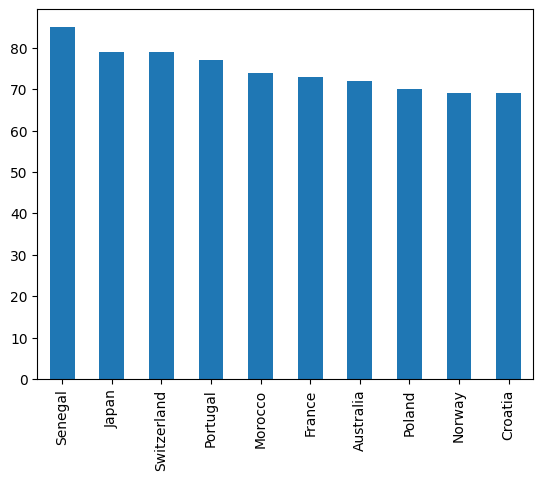

In [26]:
team_counts.head(10).plot(kind='bar')

In [27]:
df

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Home_Win_Pct,Away_Win_Pct,Clean_Sheet_Pct,Host_Advantage,Continent_Advantage,Result,Year,Month,Total Goals,Rank Difference
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,42,41,41,1,1,Home Win,2015,1,3,23
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,52,40,38,0,1,Home Win,2015,1,5,9
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,45,77,27,0,1,Away Win,2015,1,8,3
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,68,56,48,1,1,Away Win,2015,1,9,-10
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,58,80,52,0,0,Away Win,2015,1,3,-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23-09-2017,World Cup,France,Morocco,2,29,2185,2144,5,...,56,44,63,1,1,Home Win,2017,9,6,-27
996,997,24-09-2017,Nations League,Portugal,Norway,26,27,1853,2079,0,...,54,69,49,0,1,Away Win,2017,9,3,-1
997,998,25-09-2017,WC Qualifier,Portugal,England,2,24,1872,1862,3,...,73,80,46,1,0,Home Win,2017,9,4,-22
998,999,26-09-2017,WC Qualifier,Denmark,Argentina,28,15,1957,2068,0,...,68,63,52,0,1,Away Win,2017,9,5,13


In [28]:
df

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Home_Win_Pct,Away_Win_Pct,Clean_Sheet_Pct,Host_Advantage,Continent_Advantage,Result,Year,Month,Total Goals,Rank Difference
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,42,41,41,1,1,Home Win,2015,1,3,23
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,52,40,38,0,1,Home Win,2015,1,5,9
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,45,77,27,0,1,Away Win,2015,1,8,3
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,68,56,48,1,1,Away Win,2015,1,9,-10
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,58,80,52,0,0,Away Win,2015,1,3,-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23-09-2017,World Cup,France,Morocco,2,29,2185,2144,5,...,56,44,63,1,1,Home Win,2017,9,6,-27
996,997,24-09-2017,Nations League,Portugal,Norway,26,27,1853,2079,0,...,54,69,49,0,1,Away Win,2017,9,3,-1
997,998,25-09-2017,WC Qualifier,Portugal,England,2,24,1872,1862,3,...,73,80,46,1,0,Home Win,2017,9,4,-22
998,999,26-09-2017,WC Qualifier,Denmark,Argentina,28,15,1957,2068,0,...,68,63,52,0,1,Away Win,2017,9,5,13


In [29]:
teams_df

,Team
0,Germany
1,Norway
2,Nigeria
3,Croatia
4,Denmark
5,Argentina
6,Spain
7,Belgium
8,Japan
9,France


In [30]:
#Count wins per team

In [31]:
home_wins = df[df['Home_Goals'] > df['Away_Goals']]['Home_Team']
away_wins = df[df['Away_Goals'] > df['Home_Goals']]['Away_Team']

wins = pd.concat([home_wins, away_wins]).value_counts()

In [32]:
wins

,count
Senegal,39
Japan,38
France,37
Netherlands,36
Nigeria,33
Argentina,32
Norway,32
Brazil,32
Sweden,31
Morocco,31


In [33]:
matches_played = pd.concat([
    df['Home_Team'],
    df['Away_Team']
]).value_counts()

In [34]:
matches_played

,count
Senegal,85
Japan,79
Switzerland,79
Portugal,77
Morocco,74
France,73
Australia,72
Poland,70
Norway,69
Croatia,69


In [35]:
#WIN % by each teams

In [36]:
win_percent = (wins / matches_played) * 100
win_percent = win_percent.fillna(0)

win_percent.head(15)

,count
Argentina,47.761194
Australia,37.500000
Austria,34.375000
Belgium,42.187500
Brazil,50.000000
Canada,47.619048
Colombia,34.482759
Croatia,40.579710
Denmark,43.283582
England,36.363636


In [37]:
#converting all into DATA Frame
win_df = pd.DataFrame({
    'Team': matches_played.index,
    'Matches_Played': matches_played.values,
    'Wins': matches_played.index.map(wins).fillna(0).values,
    'Win %': win_percent.values
})

win_df.head(15)

,Team,Matches_Played,Wins,Win %
0,Senegal,85,39,47.761194
1,Japan,79,38,37.500000
2,Switzerland,79,30,34.375000
3,Portugal,77,28,42.187500
4,Morocco,74,31,50.000000
5,France,73,37,47.619048
6,Australia,72,27,34.482759
7,Poland,70,24,40.579710
8,Norway,69,32,43.283582
9,Croatia,69,28,36.363636


In [38]:
#Top 10 Teams by Win%

In [39]:
win_df.sort_values('Win %', ascending=False).head(10)

,Team,Matches_Played,Wins,Win %
16,England,66,24,53.731343
10,Germany,68,23,50.684932
4,Morocco,74,31,50.000000
17,Serbia,65,23,48.529412
25,Colombia,58,20,48.437500
13,Argentina,67,32,48.101266
0,Senegal,85,39,47.761194
14,Turkey,67,22,47.619048
5,France,73,37,47.619048
18,Belgium,64,27,46.376812


In [40]:
win_df

,Team,Matches_Played,Wins,Win %
0,Senegal,85,39,47.761194
1,Japan,79,38,37.500000
2,Switzerland,79,30,34.375000
3,Portugal,77,28,42.187500
4,Morocco,74,31,50.000000
5,France,73,37,47.619048
6,Australia,72,27,34.482759
7,Poland,70,24,40.579710
8,Norway,69,32,43.283582
9,Croatia,69,28,36.363636


In [41]:
all_teams

{'Argentina',
 'Australia',
 'Austria',
 'Belgium',
 'Brazil',
 'Canada',
 'Colombia',
 'Croatia',
 'Denmark',
 'England',
 'France',
 'Germany',
 'Italy',
 'Japan',
 'Mexico',
 'Morocco',
 'Netherlands',
 'Nigeria',
 'Norway',
 'Poland',
 'Portugal',
 'Senegal',
 'Serbia',
 'South Korea',
 'Spain',
 'Sweden',
 'Switzerland',
 'Turkey',
 'USA',
 'Uruguay'}

In [42]:
teams_df

,Team
0,Germany
1,Norway
2,Nigeria
3,Croatia
4,Denmark
5,Argentina
6,Spain
7,Belgium
8,Japan
9,France


In [43]:
df

,Match_ID,Date,Competition,Home_Team,Away_Team,Home_Rank,Away_Rank,Home_Elo,Away_Elo,Home_Goals,...,Home_Win_Pct,Away_Win_Pct,Clean_Sheet_Pct,Host_Advantage,Continent_Advantage,Result,Year,Month,Total Goals,Rank Difference
0,1,02-01-2015,Continental Cup,Morocco,Sweden,30,7,2160,2171,3,...,42,41,41,1,1,Home Win,2015,1,3,23
1,2,03-01-2015,World Cup,Poland,USA,19,10,2034,2157,3,...,52,40,38,0,1,Home Win,2015,1,5,9
2,3,04-01-2015,Nations League,Mexico,Canada,27,24,2179,2165,3,...,45,77,27,0,1,Away Win,2015,1,8,3
3,4,05-01-2015,Nations League,Poland,Canada,13,23,2058,2008,4,...,68,56,48,1,1,Away Win,2015,1,9,-10
4,5,06-01-2015,Nations League,Argentina,Sweden,22,30,2184,1866,1,...,58,80,52,0,0,Away Win,2015,1,3,-8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,23-09-2017,World Cup,France,Morocco,2,29,2185,2144,5,...,56,44,63,1,1,Home Win,2017,9,6,-27
996,997,24-09-2017,Nations League,Portugal,Norway,26,27,1853,2079,0,...,54,69,49,0,1,Away Win,2017,9,3,-1
997,998,25-09-2017,WC Qualifier,Portugal,England,2,24,1872,1862,3,...,73,80,46,1,0,Home Win,2017,9,4,-22
998,999,26-09-2017,WC Qualifier,Denmark,Argentina,28,15,1957,2068,0,...,68,63,52,0,1,Away Win,2017,9,5,13


## **match results (Win/Loss/Draw)**

In [44]:
import numpy as np

df['Home_Win'] = df['Home_Goals'] > df['Away_Goals']
df['Away_Win'] = df['Away_Goals'] > df['Home_Goals']
df['Draw'] = df['Home_Goals'] == df['Away_Goals']


In [45]:
#Home_Stat

In [46]:
home = df.groupby('Home_Team').agg(
    Matches=('Home_Team', 'count'),
    Wins=('Home_Win', 'sum'),
    Goals=('Home_Goals', 'sum')
).reset_index()

home.columns = ['Team', 'Matches', 'Wins', 'Goals']

In [47]:
#Away_Stat

In [48]:
away =df.groupby('Away_Team').agg(
    Matches=('Away_Team', 'count'),
    Wins=('Away_Win', 'sum'),
    Goals=('Away_Goals', 'sum')
).reset_index()
away.columns = ['Team', 'Matches', 'Wins', 'Goals']

In [49]:
#Combine Both

In [50]:
team_stats = pd.concat([home, away]).groupby('Team').sum().reset_index()

In [51]:
team_stats

,Team,Matches,Wins,Goals
0,Argentina,67,32,184
1,Australia,72,27,184
2,Austria,64,22,140
3,Belgium,64,27,166
4,Brazil,64,32,192
5,Canada,63,30,161
6,Colombia,58,20,125
7,Croatia,69,28,174
8,Denmark,67,29,163
9,England,66,24,154


In [52]:
team_stats['Win %'] = (team_stats['Wins'] / team_stats['Matches']) * 100

In [53]:
team_stats = team_stats.sort_values(by='Win %', ascending=False)
team_stats.head(10)

,Team,Matches,Wins,Goals,Win %
16,Netherlands,67,36,185,53.731343
10,France,73,37,192,50.684932
4,Brazil,64,32,192,50.000000
17,Nigeria,68,33,167,48.529412
25,Sweden,64,31,164,48.437500
13,Japan,79,38,224,48.101266
0,Argentina,67,32,184,47.761194
14,Mexico,63,30,168,47.619048
5,Canada,63,30,161,47.619048
18,Norway,69,32,184,46.376812


Let have some Graph Analysis

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

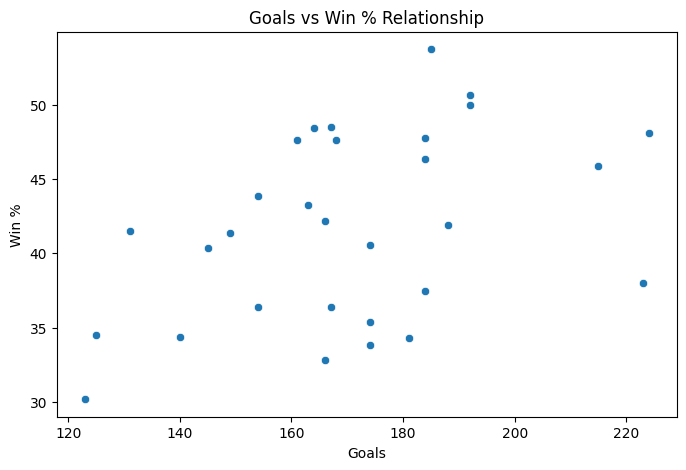

In [55]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=team_stats, x='Goals', y='Win %')
plt.title("Goals vs Win % Relationship")
plt.show()

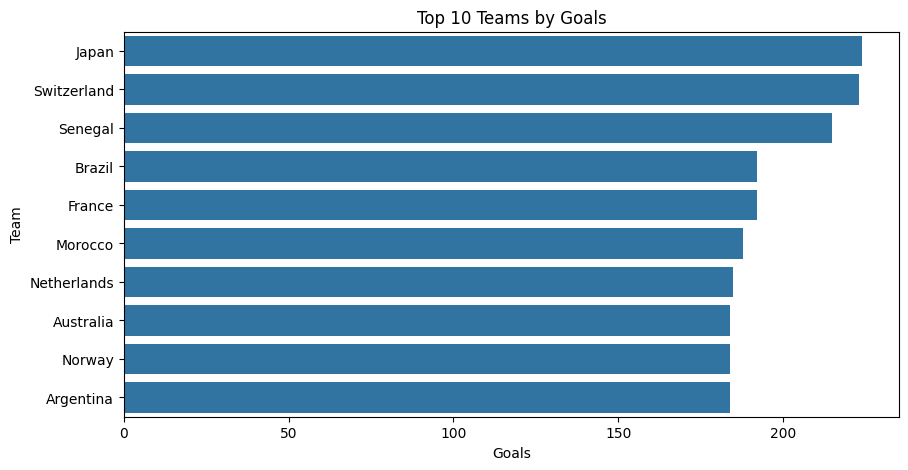

In [56]:
top_goals = team_stats.sort_values('Goals', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Goals', y='Team', data=top_goals)
plt.title("Top 10 Teams by Goals")
plt.show()

#TOP 10 TEAMS BY GOALS

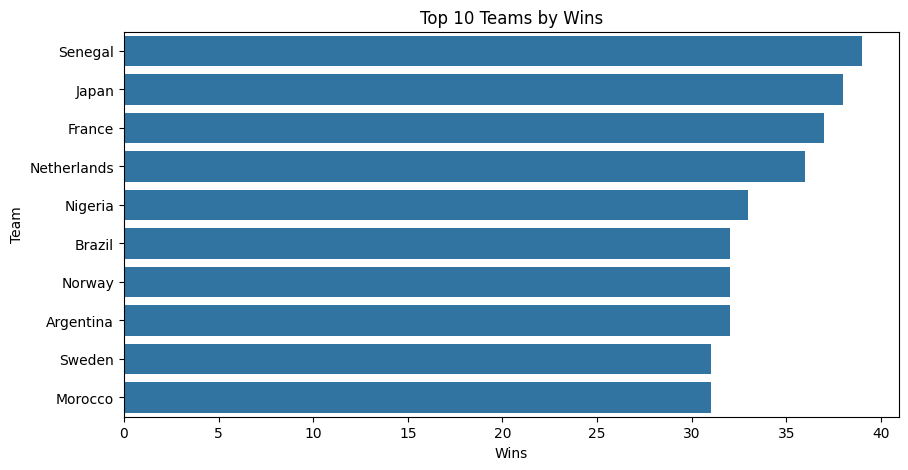

In [57]:
top_wins = team_stats.sort_values('Wins', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='Wins', y='Team', data=top_wins)
plt.title("Top 10 Teams by Wins")
plt.show()

#top 10 Teams by Wins

In [61]:
df['Result'] = np.where(
    df['Home_Goals'] > df['Away_Goals'], 1,
    np.where(df['Home_Goals'] < df['Away_Goals'], -1, 0)
)

#Giving a value to wining team and losing team


In [59]:
df['Result']

,Result
0,1
1,1
2,-1
3,-1
4,-1
...,...
995,1
996,-1
997,1
998,-1


In [62]:
df['Elo_Diff'] = df['Home_Elo'] - df['Away_Elo']
df['Form_Diff'] = df['Home_Form'] - df['Away_Form']
df['WinPct_Diff'] = df['Home_Win_Pct'] - df['Away_Win_Pct']

### MODEL CREATING (MACHINE LEARNING)

In [63]:
features = [
    'Home_Rank',
    'Away_Rank',
    'Home_Elo',
    'Away_Elo',
    'Home_Form',
    'Away_Form',
    'Home_Win_Pct',
    'Away_Win_Pct',
    'Clean_Sheet_Pct',
    'Host_Advantage',
    'Continent_Advantage',
    'Rank Difference'
]

X = df[features]
y = df['Result']

In [65]:
#Train model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [66]:
#Split Data


In [81]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 12)
(200, 12)


In [82]:
#800 row -- 12 column

In [68]:
#Training the model


In [69]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [70]:
#Predict the model output

In [83]:
predictions = model.predict(X_test)

predictions[:10]

array([-1, -1,  1, -1,  1,  1,  1,  1,  0,  1])

In [84]:
#it's showing prediction of win for 10 match from starting

In [87]:
#let's check accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.47


In [72]:
#AFTER ACCURACY LET CHECK THE FEATURES IMPORTANCE

In [85]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
3,Away_Elo,0.112449
5,Away_Form,0.111041
2,Home_Elo,0.107147
4,Home_Form,0.107096
6,Home_Win_Pct,0.096336
8,Clean_Sheet_Pct,0.092120
7,Away_Win_Pct,0.090205
11,Rank Difference,0.085202
1,Away_Rank,0.081279
0,Home_Rank,0.079751


In [74]:
#This show ELO MATTER MOST

In [88]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[44  1 39]
 [11  0 11]
 [43  1 50]]


In [75]:
# if ELO matter then let's make a table for this in which we will make Team name , Elo with home and advantage for better understanding and analysis

In [99]:
team_strength = df.groupby('Home_Team').agg({
    'Home_Rank':'mean',
    'Home_Elo':'mean',
    'Home_Form':'mean',
    'Home_Win_Pct':'mean'
}).reset_index()

team_strength.head(10)

,Home_Team,Home_Rank,Home_Elo,Home_Form,Home_Win_Pct
0,Argentina,12.939394,1971.575758,3.544242,63.424242
1,Australia,11.517241,1953.413793,3.690345,62.379310
2,Austria,15.935484,2000.225806,3.420645,61.645161
3,Belgium,15.466667,1979.300000,3.198000,64.366667
4,Brazil,14.653846,1970.307692,3.667692,60.230769
5,Canada,14.837838,1996.135135,3.562703,63.729730
6,Colombia,16.064516,1959.709677,3.520323,61.064516
7,Croatia,15.382353,1983.941176,3.421471,65.264706
8,Denmark,17.029412,1960.529412,3.669412,62.617647
9,England,14.871795,1964.076923,3.389231,61.666667


In [77]:
features = [
    'Home_Rank',
    'Away_Rank',
    'Home_Elo',
    'Away_Elo',
    'Home_Form',
    'Away_Form',
    'Home_Win_Pct',
    'Away_Win_Pct',
    'Clean_Sheet_Pct',
    'Host_Advantage',
    'Continent_Advantage',
    'Rank Difference'
]

X = df[features]
y = df['Result']

In [78]:
print(X.shape)
print(y.value_counts())

(1000, 12)
Result
 1    424
-1    414
 0    162
Name: count, dtype: int64


In [80]:
#Home win -- 424
#Away win -- 414
#Draw -- 162

In [89]:
team_strength.sort_values(
    by='Home_Elo',
    ascending=False
).head(10)

,Home_Team,Home_Rank,Home_Elo,Home_Form,Home_Win_Pct
2,Austria,15.935484,2000.225806,3.420645,61.645161
5,Canada,14.837838,1996.135135,3.562703,63.729730
14,Mexico,15.032258,1994.741935,3.424516,63.580645
18,Norway,16.918919,1994.648649,3.728108,65.702703
29,Uruguay,15.935484,1991.709677,3.688387,61.451613
26,Switzerland,17.416667,1987.000000,3.609444,62.166667
23,South Korea,17.000000,1986.956522,3.812609,58.565217
12,Italy,14.782609,1986.391304,3.617826,66.521739
15,Morocco,14.882353,1984.705882,3.525294,65.264706
7,Croatia,15.382353,1983.941176,3.421471,65.264706


## Let's Have some Graph to now more about outcome

In [93]:
#Top win teams by win percentage

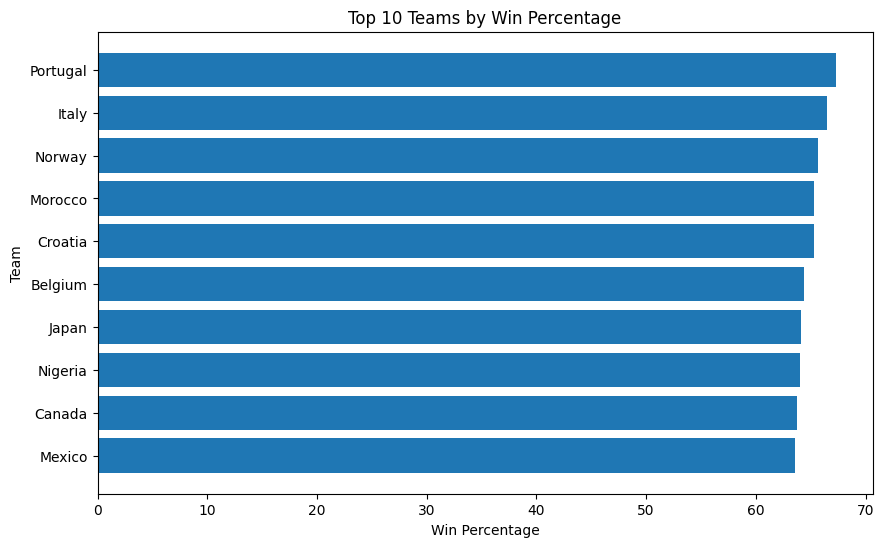

In [92]:
top_win = team_strength.sort_values(
    by='Home_Win_Pct',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_win['Home_Team'], top_win['Home_Win_Pct'])
plt.title('Top 10 Teams by Win Percentage')
plt.xlabel('Win Percentage')
plt.ylabel('Team')
plt.gca().invert_yaxis()
plt.show()

In [94]:
#Team Form vs Elo Scatter Plot

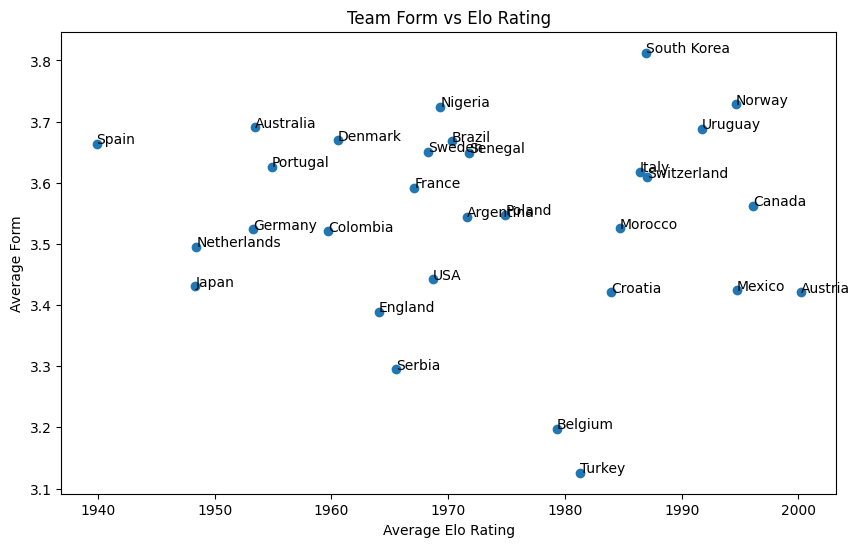

In [95]:
plt.figure(figsize=(10,6))

plt.scatter(
    team_strength['Home_Elo'],
    team_strength['Home_Form']
)

for i in range(len(team_strength)):
    plt.annotate(
        team_strength['Home_Team'].iloc[i],
        (
            team_strength['Home_Elo'].iloc[i],
            team_strength['Home_Form'].iloc[i]
        )
    )

plt.title('Team Form vs Elo Rating')
plt.xlabel('Average Elo Rating')
plt.ylabel('Average Form')
plt.show()